<center> <a href="https://github.com/CyConProject?tab=repositories">
  <img src="https://github.com/CyConProject/Lab/blob/main/Figures/CyCon.png?raw=true" alt="logo" width="80" >
</a>
 </center>


## Experiments with Activation and Gradient Issues


In many **civil-engineering deep-learning applications**, such as crack detection from images, structural health monitoring from sensor streams, equipment-failure prediction, and traffic-state forecasting, the choice of activation function has a major effect on how well a neural network learns.  

In this lab, you will explore how common activation functions behave, why some functions suffer from **vanishing gradients**, and why **ReLU** is often the default starting point for hidden layers in modern deep learning.

You will:

* compare the shapes of common activation functions and their derivatives,
* inspect saturation and gradient shrinkage at different input values,
* simulate how gradients can disappear across many layers,
* and compare gradient flow in a small deep network using different hidden-layer activations.

> **Why this matters in civil engineering:** A deep model is only useful if it can actually learn from data. If early layers learn too slowly, the model may miss subtle patterns such as early-stage structural damage, pavement distress, or abnormal machinery behavior.


### Objectives

1. Implement and test activation functions and their derivatives.
2. Visualize how gradients behave for sigmoid, tanh, ReLU, and leaky ReLU.
3. Show how repeated multiplication of small derivatives leads to vanishing gradients.
4. Compare layer-by-layer gradient strength in a toy deep network.
5. Connect activation choice to practical modeling decisions in civil-engineering problems.


## 1. Recap: Why Activation Choice Matters

For layer $l$ in a neural network,

$$
z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)},
\qquad
 a^{(l)} = \phi\left(z^{(l)}\right)
$$

where $\phi$ is the activation function.

During backpropagation, the error signal at one layer depends on the next layer **and** on the derivative of the activation function:

$$
\delta^{(l)} = \left(W^{(l+1)}\right)^T \delta^{(l+1)} \odot \phi'\left(z^{(l)}\right)
$$

This means the gradient is repeatedly multiplied by terms involving $\phi'(z)$. If those derivative values are very small, the gradient can shrink toward zero as it moves backward through many layers.

### Key ideas

1. **Sigmoid** outputs values in $(0,1)$, but its derivative becomes very small for large positive or negative inputs.
2. **tanh** is zero-centered, which is often better than sigmoid, but it can still saturate and produce small gradients.
3. **ReLU** has derivative $1$ for positive inputs and $0$ for negative inputs, which helps active neurons keep stronger gradients.
4. **Leaky ReLU** keeps a small nonzero slope for negative inputs, reducing the chance that neurons become permanently inactive.
5. **Softmax** is typically used in the **output layer** for multi-class classification, not as the default hidden-layer activation.

> **Practical takeaway:** For many hidden-layer deep-learning models, a good first choice is **ReLU**. If inactive neurons become a problem, **leaky ReLU** is a common alternative.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

## 2. Part I – Build Activation and Gradient Functions

We will work with four hidden-layer activation choices:

1. **Sigmoid**
2. **tanh**
3. **ReLU**
4. **Leaky ReLU**

The first step is to define the activation functions themselves.
> **Implementation note:** At $z=0$, **ReLU** and **leaky ReLU** are not differentiable in the strict mathematical sense. In this lab, we use the common implementation convention:
> * ReLU derivative at $z=0$ is taken as $0$
> * leaky ReLU derivative at $z=0$ is taken as $\alpha$

In [2]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def tanh(z):
    return np.tanh(z)


def relu(z):
    return np.maximum(0.0, z)

> **Exercise 1:** Complete the missing functions below.
>
> Define:
> 1. `sigmoid_derivative(z)` using the identity $\sigma'(z) = \sigma(z)(1-\sigma(z))$
> 2. `tanh_derivative(z)`
> 3. `leaky_relu(z, alpha=0.05)`
> 4. `leaky_relu_derivative(z, alpha=0.05)`
>
> Use a small negative-side slope of `0.05` for leaky ReLU.


In [3]:
# TODO: Write your code here

# def sigmoid_derivative(z):
#     ...

# def tanh_derivative(z):
#     ...

# def leaky_relu(z, alpha=0.05):
#     ...

# def leaky_relu_derivative(z, alpha=0.05):
#     ...

<details>
<summary> Solutions (click to expand)</summary>

```python
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1.0 - s)


def tanh_derivative(z):
    return 1.0 - np.tanh(z)**2


def leaky_relu(z, alpha=0.05):
    return np.where(z > 0, z, alpha * z)


def leaky_relu_derivative(z, alpha=0.05):
    return np.where(z > 0, 1.0, alpha)
```

</details>

## 3. Part II – Plot Activation Curves and Gradient Curves

To understand why activation choice matters, we will compare both:

* the **activation output** $\phi(z)$, and
* the **gradient** $\phi'(z)$

for a range of pre-activation values.

In deep networks used for structural monitoring or image-based inspection, large positive or negative internal values can appear as data passes through many layers. If the derivative becomes too small, learning slows down.


In [5]:
# TODO: Generate 400 values between -8 and 8, then compute
# the activation outputs and derivatives for all four functions.

# z = ...
# sigmoid_vals = ...
# tanh_vals = ...
# relu_vals = ...
# leaky_vals = ...
# sigmoid_grad = ...
# tanh_grad = ...
# relu_grad = ...
# leaky_grad = ...

<details>
<summary> Solutions (click to expand)</summary>

```python
z = np.linspace(-8, 8, 400)

sigmoid_vals = sigmoid(z)
tanh_vals = tanh(z)
relu_vals = relu(z)
leaky_vals = leaky_relu(z)

sigmoid_grad = sigmoid_derivative(z)
tanh_grad = tanh_derivative(z)
relu_grad = relu_derivative = np.where(z > 0, 1.0, 0.0)
leaky_grad = leaky_relu_derivative(z)
```

</details>

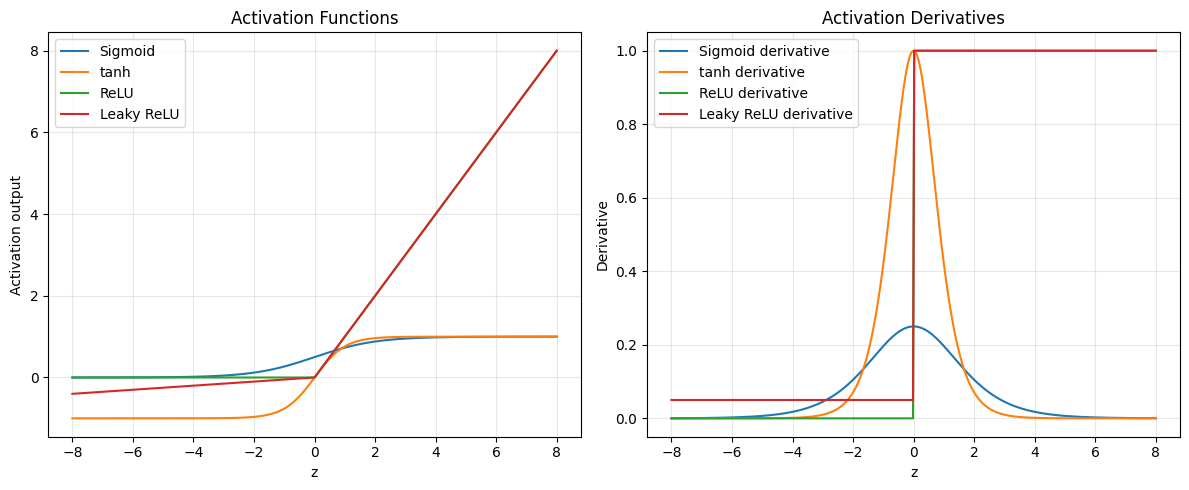

In [7]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(z, sigmoid_vals, label='Sigmoid')
plt.plot(z, tanh_vals, label='tanh')
plt.plot(z, relu_vals, label='ReLU')
plt.plot(z, leaky_vals, label='Leaky ReLU')
plt.xlabel('z')
plt.ylabel('Activation output')
plt.title('Activation Functions')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(z, sigmoid_grad, label='Sigmoid derivative')
plt.plot(z, tanh_grad, label='tanh derivative')
plt.plot(z, relu_grad, label='ReLU derivative')
plt.plot(z, leaky_grad, label='Leaky ReLU derivative')
plt.xlabel('z')
plt.ylabel('Derivative')
plt.title('Activation Derivatives')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> **Exercise 2:** Based on the plots, answer the following:
>
> 1. Which functions clearly **saturate** for large positive or negative values?
> 2. Which hidden-layer activation keeps a gradient of about **1** on its active side?
> 3. Why might leaky ReLU be preferred over standard ReLU in some models?


<details>
<summary> Solutions (click to expand)</summary>

**Suggested answers:**

1. **Sigmoid** and **tanh** saturate for large-magnitude inputs. Their outputs flatten out, and their derivatives become very small.
2. **ReLU** keeps a derivative of **1** for positive inputs, which helps active neurons preserve stronger gradients.
3. **Leaky ReLU** can be preferred because it keeps a small negative-side slope, so neurons are less likely to get stuck with zero gradient on all negative inputs.

> **Interpretation:** Sigmoid and tanh can be useful, but in very deep hidden stacks they often make learning slower because the gradient shrinks as it moves backward through many layers.

</details>

## 4. Part III – Saturation Experiment at Specific Input Values

Now let us inspect a few specific pre-activation values:

$$
z \in \{-8, -2, 0, 2, 8\}
$$

These values help us see what happens when a neuron is strongly negative, near the middle of the curve, or strongly positive.

Imagine these as internal values produced by a deep structural-damage classifier before activation is applied.


In [8]:
# TODO: For z_test = [-8, -2, 0, 2, 8], print the activation output
# and derivative for sigmoid, tanh, ReLU, and leaky ReLU.

# z_test = ...
# for each activation:
#     print(name, outputs, gradients)

<details>
<summary> Solutions (click to expand)</summary>

```python
z_test = np.array([-8., -2., 0., 2., 8.])

functions = [
    ('Sigmoid', sigmoid, sigmoid_derivative),
    ('tanh', tanh, tanh_derivative),
    ('ReLU', relu, lambda z: np.where(z > 0, 1.0, 0.0)),
    ('Leaky ReLU', leaky_relu, leaky_relu_derivative)
]

for name, fn, dfn in functions:
    print(f'\n{name}')
    print('z         =', z_test)
    print('outputs   =', np.round(fn(z_test), 6))
    print('gradients =', np.round(dfn(z_test), 6))
```

**What you should notice:**

* For **sigmoid**, derivatives near $z=-8$ and $z=8$ are extremely small.
* For **tanh**, the same saturation behavior appears at large magnitudes.
* For **ReLU**, gradients are either $0$ or $1$.
* For **leaky ReLU**, the negative side keeps a small but nonzero gradient.

</details>

> **Observation:** The derivative values explain the training behavior.
>
> If a neuron keeps producing large-magnitude pre-activations, then for **sigmoid** or **tanh** the local gradient becomes tiny. Once this happens repeatedly across many layers, the earliest layers receive almost no learning signal.


## 5. Part IV – Chain Rule and Gradient Shrinkage Across Depth

The vanishing-gradient problem is fundamentally a **multiplication problem**. During backpropagation, many derivative terms are multiplied together.

In this section, we will define a simple measure of gradient strength along one path through a deep network:

$$
\text{chain strength} = \prod_{l=1}^{L} \left|\phi'(z^{(l)})\right|
$$

If this product becomes extremely small, the gradient arriving at early layers becomes negligible.
> **Note:** This is a simplified teaching metric that isolates the effect of activation derivatives only. In a full neural network, gradient flow also depends on the weight matrices and the activations from earlier layers.


In [10]:
# TODO: Complete a helper function that multiplies the absolute values
# of the derivatives along a path of hidden layers.

# def chain_strength(z_values, derivative_fn):
#     ...

# Then evaluate it on the following path:
# z_path = np.array([4.5, -4.0, 3.8, -5.1, 4.7, -4.4, 3.9, -4.8])
# for sigmoid, tanh, ReLU, and leaky ReLU.

<details>
<summary> Solutions (click to expand)</summary>

```python
def chain_strength(z_values, derivative_fn):
    return float(np.prod(np.abs(derivative_fn(z_values))))

z_path = np.array([4.5, -4.0, 3.8, -5.1, 4.7, -4.4, 3.9, -4.8])

print('Chain strength on one 8-layer path:')
print('Sigmoid    :', chain_strength(z_path, sigmoid_derivative))
print('tanh       :', chain_strength(z_path, tanh_derivative))
print('ReLU       :', chain_strength(z_path, lambda z: np.where(z > 0, 1.0, 0.0)))
print('Leaky ReLU :', chain_strength(z_path, leaky_relu_derivative))
```

**Expected interpretation:**

* **Sigmoid** and **tanh** produce extremely small chain strengths on saturated inputs.
* **ReLU** can produce an exact zero if any neuron on the path is inactive.
* **Leaky ReLU** still shrinks the gradient on negative values, but it avoids an exact zero on that side.

</details>

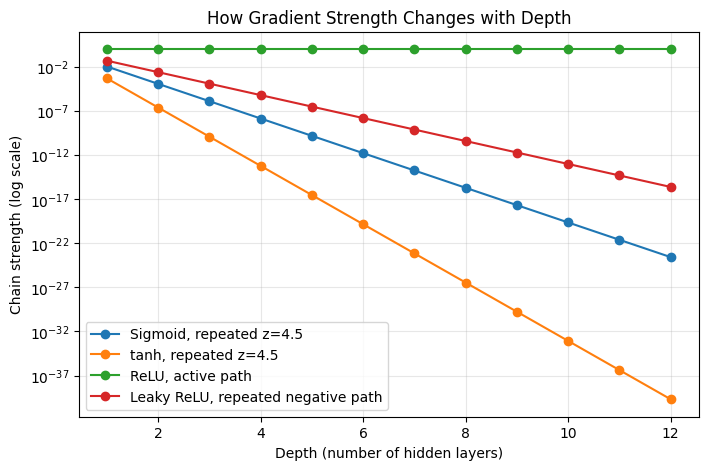

In [12]:

# A second view: repeated saturation at z = 4.5 across increasing depth

depths = np.arange(1, 13)
sigmoid_curve = np.array([(sigmoid_derivative(4.5))**d for d in depths], dtype=float)
tanh_curve = np.array([(np.abs(tanh_derivative(4.5)))**d for d in depths], dtype=float)
relu_active_curve = np.ones_like(depths, dtype=float)
leaky_negative_curve = np.array([(0.05)**d for d in depths], dtype=float)

plt.figure(figsize=(8, 5))
plt.semilogy(depths, sigmoid_curve, marker='o', label='Sigmoid, repeated z=4.5')
plt.semilogy(depths, tanh_curve, marker='o', label='tanh, repeated z=4.5')
plt.semilogy(depths, relu_active_curve, marker='o', label='ReLU, active path')
plt.semilogy(depths, leaky_negative_curve, marker='o', label='Leaky ReLU, repeated negative path')
plt.xlabel('Depth (number of hidden layers)')
plt.ylabel('Chain strength (log scale)')
plt.title('How Gradient Strength Changes with Depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Part V – Mini Deep-Network Backward-Signal Experiment

So far, we studied gradients through formulas and isolated paths. Next, we will run a **toy deep-network experiment**.

We will:

1. build the **same** small dense network,
2. use different hidden-layer activations,
3. perform one forward pass and one backward pass,
4. compare the **gradient norm** at each layer.

This is not a full training loop. The goal is only to inspect how much learning signal reaches earlier layers.
> **Important note:** In this toy experiment, the observed gradient norms depend on the activation function, the weights, the biases, and the specific input. Depending on the initialization, you may see not only **vanishing gradients** but also **large or exploding gradients**. The goal is to compare qualitative gradient-flow behavior across activations, not to claim that only vanishing gradients can occur.

In [13]:
def init_dense_network(layer_sizes, weight_scale=1.2, seed=7):
    rng = np.random.default_rng(seed)
    params = []
    for in_size, out_size in zip(layer_sizes[:-1], layer_sizes[1:]):
        params.append({
            'W': rng.normal(0.0, weight_scale, size=(out_size, in_size)),
            'b': rng.normal(0.0, weight_scale, size=(out_size, 1))
        })
    return params


def forward_hidden_network(params, x, activation_fn):
    a = np.array(x, dtype=float).reshape(-1, 1)
    activations = [a]
    pre_activations = []

    # hidden layers
    for layer in params[:-1]:
        z = layer['W'] @ a + layer['b']
        a = activation_fn(z)
        pre_activations.append(z)
        activations.append(a)

    # output layer (linear output for simplicity)
    z_out = params[-1]['W'] @ a + params[-1]['b']
    pre_activations.append(z_out)
    activations.append(z_out)

    return activations, pre_activations


def backward_gradient_norms(params, activations, pre_activations, y_true, activation_derivative):
    y_true = np.array(y_true, dtype=float).reshape(-1, 1)

    # For a linear output with MSE, dL/dz_out is proportional to (y_hat - y)
    delta = activations[-1] - y_true
    grad_norms = []

    # Output layer gradient norm
    dW = delta @ activations[-2].T
    grad_norms.append(np.linalg.norm(dW))

    # Hidden layers (moving backward)
    for l in range(len(params) - 2, -1, -1):
        delta = (params[l + 1]['W'].T @ delta) * activation_derivative(pre_activations[l])
        dW = delta @ activations[l].T
        grad_norms.append(np.linalg.norm(dW))

    return grad_norms[::-1]


Sigmoid
gradient norms by layer = [0.016585 0.036123 0.093549 0.389925 1.587798 2.207046]

tanh
gradient norms by layer = [42.167765 69.630825 52.339059 24.069715  9.300325  3.336958]

ReLU
gradient norms by layer = [809.881809 695.308733 439.944638 586.565481 744.47907  344.975673]

Leaky ReLU
gradient norms by layer = [447.692433 369.716468 326.764021 596.935729 584.734779 206.347734]


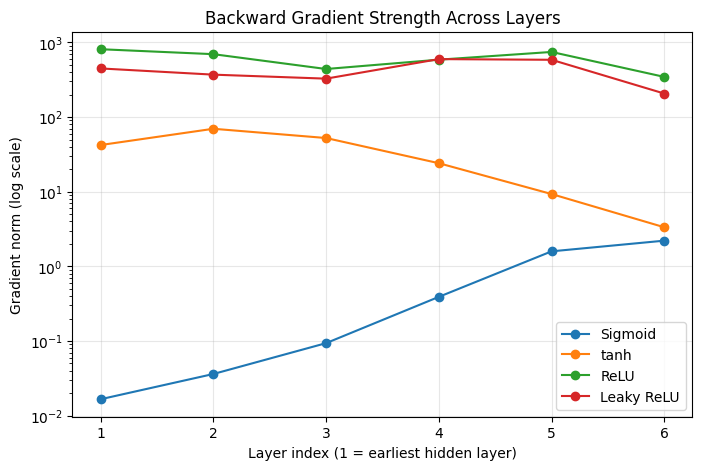

In [14]:
layer_sizes = [3, 10, 10, 10, 10, 10, 1]   # 5 hidden layers
params = init_dense_network(layer_sizes, weight_scale=1.2, seed=7)

# Example normalized civil-engineering sensor vector:
# [vibration, strain, temperature_shift]
x = np.array([1.5, -1.0, 0.6])
y_true = np.array([0.35])

experiments = [
    ('Sigmoid', sigmoid, sigmoid_derivative),
    ('tanh', tanh, tanh_derivative),
    ('ReLU', relu, lambda z: np.where(z > 0, 1.0, 0.0)),
    ('Leaky ReLU', leaky_relu, leaky_relu_derivative)
]

plt.figure(figsize=(8, 5))

for name, act_fn, dact_fn in experiments:
    activations, pre_activations = forward_hidden_network(params, x, act_fn)
    norms = np.array(backward_gradient_norms(params, activations, pre_activations, y_true, dact_fn))

    print(f'\n{name}')
    print('gradient norms by layer =', np.round(norms, 10))

    # Avoid log-scale plotting issues when the norm is exactly zero
    safe_norms = np.maximum(norms, 1e-12)
    plt.plot(range(1, len(safe_norms) + 1), safe_norms, marker='o', label=name)

plt.yscale('log')
plt.xlabel('Layer index (1 = earliest hidden layer)')
plt.ylabel('Gradient norm (log scale)')
plt.title('Backward Gradient Strength Across Layers')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


> **Exercise 3:** Interpret the gradient-norm plot.
>
> 1. Which activations send the weakest learning signal to the earliest hidden layers?
> 2. Which activation usually gives the strongest gradient flow on active paths?
> 3. Why might **leaky ReLU** outperform standard ReLU in some networks?
> 4. In a civil-engineering damage-detection model, why is weak gradient flow in early layers a practical problem?


<details>
<summary> Solutions (click to expand)</summary>

**Suggested interpretation:**

1. **Sigmoid** usually sends the weakest signal to the earliest hidden layers because its derivatives are often much smaller than 1 once activations saturate. **tanh** can also weaken the signal, although often less severely near zero.
2. **ReLU** usually gives the strongest gradient flow on active paths because its derivative is 1 for positive inputs.
3. **Leaky ReLU** can outperform ReLU because it keeps a small gradient on the negative side instead of dropping to exactly zero.
4. In civil-engineering applications, the first hidden layers may need to learn subtle low-level patterns such as fine crack edges, gradual changes in vibration signatures, or weak anomaly indicators. If gradients vanish there, those early features may never be learned well.

> **Important note:** Exact numerical results depend on the random weights and inputs. The pattern is what matters: sigmoid/tanh often shrink gradients, ReLU preserves gradients on active units, and leaky ReLU helps avoid zero-gradient dead zones.

</details>

## 7. Part VI – Experiments & Extensions

Try one or more of these follow-up experiments:

1. **Increase depth** from 5 hidden layers to 8 hidden layers. What happens to the earliest-layer gradient norms?
2. **Reduce the weight scale** from `1.2` to `0.2`. Does sigmoid still saturate as strongly?
3. **Make the input more negative** and compare ReLU vs. leaky ReLU. Which one preserves more gradient?
4. **Switch the output task** from a single regression output to a multi-class damage label. Which output activation would be appropriate then?

> **Hint:** For a multi-class output such as {no damage, minor damage, severe damage}, **softmax** is typically used in the output layer.


In [15]:
# TODO: Try one of the extension experiments here.

# Example ideas:
# - Change layer_sizes to [3, 10, 10, 10, 10, 10, 10, 10, 10, 1]
# - Change weight_scale to 0.2
# - Change x to a more negative vector
# - Replace the output interpretation with a multi-class softmax discussion

<details>
<summary> Solutions (click to expand)</summary>

**Typical trends you should observe:**

1. **More depth** usually makes vanishing gradients worse for sigmoid and tanh, because more small derivative terms are multiplied together.
2. **Smaller weight scale** often reduces saturation early in training, which can help sigmoid and tanh somewhat.
3. **More negative inputs** can make standard ReLU produce more zero-gradient inactive units, while **leaky ReLU** still preserves a small learning signal.
4. For **multi-class classification**, the usual design is:
   * **ReLU** (or leaky ReLU) in hidden layers
   * **Softmax** in the output layer

</details>

## 8. Wrap-Up

In this lab, you explored why activation functions are more than just mathematical details:

* **Sigmoid** and **tanh** can saturate and cause gradients to shrink.
* **ReLU** helped make deep learning practical by preserving stronger gradients on active neurons.
* **Leaky ReLU** addresses one of ReLU’s main weaknesses by keeping a small negative-side gradient.
* The **vanishing-gradient problem** is closely tied to repeated multiplication of small derivative values during backpropagation.

For civil engineers using deep learning, this has a direct consequence: the wrong activation choice can prevent a model from learning the subtle patterns needed for reliable prediction, classification, and condition assessment.

> In the next stage of model design, activation choice should be considered together with initialization, normalization, optimizer selection, and the structure of the training data.
